# Macierz kowariancji, wartosci/wektory wlasne i PCA — notatnik referencyjny

Ten notebook to **przypomnienie teorii** z naciskiem na matematyke — nie na praktyczne
zastosowania finansowe (te byly w innych notebookach). Kazde twierdzenie jest
wyprowadzone, a kod numpy sluzy do **zweryfikowania** wzorow na konkretnych liczbach.

**Struktura:**
1. Macierz kowariancji — definicja, wlasnosci, intuicja
2. Forma kwadratowa i transformacje liniowe kowariancji
3. Wartosci i wektory wlasne — definicja i podstawowe wlasnosci
4. Twierdzenie spektralne dla macierzy symetrycznych
5. PCA — pelne wyprowadzenie krok po kroku
6. Geometria: elipsa ryzyka i co eigenvectory naprawde znacza

---


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

print("NumPy", np.__version__)


NumPy 2.4.4


---
## 1. Macierz kowariancji

### 1.1 Definicja dla dwoch zmiennych

Dla dwoch zmiennych losowych X, Y:

$$
\text{Cov}(X, Y) = E[(X - E[X])(Y - E[Y])]
$$

Rozwiniecie do postaci czesto uzywanej w obliczeniach:

$$
\text{Cov}(X, Y) = E[XY] - E[X]E[Y]
$$

**Wlasnosci podstawowe:**
- $\text{Cov}(X, X) = \text{Var}(X)$ — kowariancja zmiennej z sama soba to jej wariancja
- $\text{Cov}(X, Y) = \text{Cov}(Y, X)$ — symetria
- $\text{Cov}(aX + b, cY + d) = ac \cdot \text{Cov}(X, Y)$ — bilinearnosc (stale wychodza przed nawias)

### 1.2 Definicja dla wektora losowego

Dla wektora losowego $\mathbf{X} = (X_1, ..., X_n)^T$, macierz kowariancji $\Sigma$ to:

$$
\Sigma_{ij} = \text{Cov}(X_i, X_j)
$$

W notacji macierzowej, jesli $\mu = E[\mathbf{X}]$:

$$
\Sigma = E\left[(\mathbf{X} - \mu)(\mathbf{X} - \mu)^T\right]
$$

To jest macierz $n \times n$. Zauwaz: $(\mathbf{X}-\mu)$ to wektor kolumnowy $(n \times 1)$,
a $(\mathbf{X}-\mu)^T$ to wektor wierszowy $(1 \times n)$ — ich iloczyn to macierz $(n \times n)$,
nie liczba (w przeciwienstwie do $(\mathbf{X}-\mu)^T(\mathbf{X}-\mu)$ ktore daje skalar).


In [2]:
# --- Weryfikacja definicji na danych symulowanych ---
np.random.seed(42)
N = 100_000

# 3 zmienne losowe o znanych prawdziwych parametrach
mu_true = np.array([0.05, -0.02, 0.10])
Sigma_true = np.array([
    [0.04,  0.012, -0.006],
    [0.012, 0.09,   0.018],
    [-0.006, 0.018, 0.0625]
])

# Generujemy dane z tego rozkladu (zeby zweryfikowac definicje empirycznie)
L = np.linalg.cholesky(Sigma_true)
Z = np.random.standard_normal((3, N))
X = mu_true[:, np.newaxis] + L @ Z   # X: (3, N)

# --- Definicja: Sigma_ij = Cov(X_i, X_j) = E[(X_i - mu_i)(X_j - mu_j)] ---
X_centered = X - X.mean(axis=1, keepdims=True)   # odejmujemy SREDNIA EMPIRYCZNA

# Recznie obliczamy Sigma[0,1] z definicji
cov_01_manual = np.mean(X_centered[0] * X_centered[1])
print(f"Cov(X1,X2) recznie z definicji: {cov_01_manual:.6f}")
print(f"Cov(X1,X2) prawdziwa:           {Sigma_true[0,1]:.6f}")
print(f"np.cov:                          {np.cov(X)[0,1]:.6f}")


Cov(X1,X2) recznie z definicji: 0.012393
Cov(X1,X2) prawdziwa:           0.012000
np.cov:                          0.012393


In [3]:
# --- Cala macierz: E[(X-mu)(X-mu)^T] jako srednia po N realizacjach ---
# Kazda kolumna X_centered[:, k] to jeden wektor (X-mu) dla obserwacji k
# (X-mu)(X-mu)^T dla jednej obserwacji to macierz (3x3) - outer product

# Recznie: usredniamy outer product po wszystkich N obserwacjach
Sigma_manual = np.zeros((3, 3))
for k in range(N):
    v = X_centered[:, k:k+1]          # (3, 1) wektor kolumnowy
    Sigma_manual += v @ v.T            # (3,1) @ (1,3) = (3,3) outer product
Sigma_manual /= (N - 1)                 # dzielimy przez N-1 (estymator nieobciazony)

print("Sigma z definicji (petla, usrednianie outer product):")
print(Sigma_manual.round(4))
print()
print("Sigma prawdziwa:")
print(Sigma_true.round(4))
print()
print("np.cov (wektoryzowane, to samo wynik):")
print(np.cov(X).round(4))


Sigma z definicji (petla, usrednianie outer product):
[[ 0.0401  0.0124 -0.0058]
 [ 0.0124  0.09    0.0177]
 [-0.0058  0.0177  0.0623]]

Sigma prawdziwa:
[[ 0.04    0.012  -0.006 ]
 [ 0.012   0.09    0.018 ]
 [-0.006   0.018   0.0625]]

np.cov (wektoryzowane, to samo wynik):
[[ 0.0401  0.0124 -0.0058]
 [ 0.0124  0.09    0.0177]
 [-0.0058  0.0177  0.0623]]


### 1.3 Wektoryzowana wersja definicji

Petla powyzej jest wolna — w praktyce liczy sie to jednym mnozeniem macierzowym:

$$
\hat\Sigma = \frac{1}{N-1} \mathbf{X}_c \mathbf{X}_c^T
$$

gdzie $\mathbf{X}_c$ to macierz $(n \times N)$ wycentrowanych danych (kazda kolumna to jedna obserwacja).
To jest dokladnie to co robi `np.cov` pod maska.


In [4]:
# --- Wektoryzowana wersja: jedno mnozenie macierzowe zamiast petli ---
Sigma_vectorized = (X_centered @ X_centered.T) / (N - 1)

print("Sigma wektoryzowana (X_c @ X_c.T / (N-1)):")
print(Sigma_vectorized.round(4))
print()
print(f"Identyczna z petla: {np.allclose(Sigma_manual, Sigma_vectorized)}")
print(f"Identyczna z np.cov: {np.allclose(np.cov(X), Sigma_vectorized)}")


Sigma wektoryzowana (X_c @ X_c.T / (N-1)):
[[ 0.0401  0.0124 -0.0058]
 [ 0.0124  0.09    0.0177]
 [-0.0058  0.0177  0.0623]]

Identyczna z petla: True
Identyczna z np.cov: True


### 1.4 Dwie kluczowe wlasnosci macierzy kowariancji

**Wlasnosc 1: Symetria.** $\Sigma = \Sigma^T$, bo $\text{Cov}(X_i,X_j) = \text{Cov}(X_j,X_i)$.

**Wlasnosc 2: Dodatnia polokreslonosc (PSD).** Dla kazdego wektora $\mathbf{w} \in \mathbb{R}^n$:

$$
\mathbf{w}^T \Sigma \mathbf{w} \geq 0
$$

**Dowod:** $\mathbf{w}^T \Sigma \mathbf{w} = \mathbf{w}^T E[(\mathbf{X}-\mu)(\mathbf{X}-\mu)^T] \mathbf{w}
= E[\mathbf{w}^T(\mathbf{X}-\mu)(\mathbf{X}-\mu)^T\mathbf{w}]
= E[(\mathbf{w}^T(\mathbf{X}-\mu))^2] \geq 0$

bo to wartosc oczekiwana **kwadratu** liczby rzeczywistej $\mathbf{w}^T(\mathbf{X}-\mu)$ — a kwadrat
zawsze jest $\geq 0$.

To jest fundamentalne: $\mathbf{w}^T\Sigma\mathbf{w}$ to po prostu $\text{Var}(\mathbf{w}^T\mathbf{X})$ —
wariancja kombinacji liniowej zawsze jest nieujemna, co jest oczywiste z definicji wariancji,
ale dowod formalny przechodzi przez te sama tozsamosc.


In [5]:
# --- Weryfikacja: w^T Sigma w = Var(w^T X) ---
w_test = np.array([0.5, -0.3, 0.8])

# Lewa strona: forma kwadratowa
lhs = w_test @ Sigma_true @ w_test

# Prawa strona: wariancja kombinacji liniowej zmiennych
combo = w_test @ X   # (3,) @ (3,N) = (N,) -- kombinacja liniowa dla kazdej obserwacji
rhs = np.var(combo, ddof=1)

print(f"w^T Sigma w (forma kwadratowa):  {lhs:.6f}")
print(f"Var(w^T X) (z danych):            {rhs:.6f}")
print(f"Identyczne: {np.isclose(lhs, rhs, rtol=1e-2)}")
print()

# Sprawdzmy ze JEST nieujemna dla wielu losowych w
print("Test PSD dla 1000 losowych wektorow w:")
all_nonneg = True
for _ in range(1000):
    w_rand = np.random.normal(0, 1, 3)
    val = w_rand @ Sigma_true @ w_rand
    if val < 0:
        all_nonneg = False
print(f"Wszystkie w^T Sigma w >= 0: {all_nonneg}")


w^T Sigma w (forma kwadratowa):  0.041060
Var(w^T X) (z danych):            0.041121
Identyczne: True

Test PSD dla 1000 losowych wektorow w:
Wszystkie w^T Sigma w >= 0: True


---
## 2. Transformacje liniowe kowariancji

### 2.1 Twierdzenie o propagacji kowariancji

Jesli $\mathbf{Y} = A\mathbf{X}$ dla pewnej stalej macierzy $A$ ($m \times n$), to:

$$
\text{Cov}(\mathbf{Y}) = A \, \Sigma \, A^T
$$

**Dowod:**

$$
\text{Cov}(\mathbf{Y}) = E[(\mathbf{Y}-E[\mathbf{Y}])(\mathbf{Y}-E[\mathbf{Y}])^T]
= E[(A\mathbf{X}-A\mu)(A\mathbf{X}-A\mu)^T]
$$

$$
= E[A(\mathbf{X}-\mu)(\mathbf{X}-\mu)^TA^T]
= A \, E[(\mathbf{X}-\mu)(\mathbf{X}-\mu)^T] \, A^T
= A\Sigma A^T
$$

$A$ wychodzi przed $E[\cdot]$ bo jest stala (nie zmienna losowa) — wartosc oczekiwana
jest operacja liniowa.

### 2.2 Szczegolny przypadek: forma kwadratowa

Jesli $A$ jest wektorem wierszowym $\mathbf{w}^T$ ($1 \times n$), to $Y = \mathbf{w}^T\mathbf{X}$
jest **skalarem**, a:

$$
\text{Var}(Y) = \mathbf{w}^T \Sigma \mathbf{w}
$$

To jest wzor na wariancje portfela — szczegolny przypadek ($m=1$) ogolnego wzoru transformacji.


In [6]:
# --- Weryfikacja: Cov(AX) = A Sigma A^T dla macierzy A (nie tylko wektora) ---

# Transformacja: 2 nowe zmienne jako kombinacje liniowe 3 oryginalnych
A = np.array([
    [1.0, -1.0,  0.0],   # Y1 = X1 - X2
    [0.5,  0.5, -1.0],   # Y2 = 0.5*X1 + 0.5*X2 - X3
])

# Metoda 1: transformuj dane, policz kowariancje empirycznie
Y = A @ X   # (2,3) @ (3,N) = (2,N)
Sigma_Y_empirical = np.cov(Y)

# Metoda 2: zastosuj wzor teoretyczny na Sigma_true
Sigma_Y_theoretical = A @ Sigma_true @ A.T

print("Cov(Y) z danych (transformacja + np.cov):")
print(Sigma_Y_empirical.round(4))
print()
print("Cov(Y) z wzoru A Sigma A^T:")
print(Sigma_Y_theoretical.round(4))
print()
print(f"Zgodnosc (tolerancja estymacji): {np.allclose(Sigma_Y_empirical, Sigma_Y_theoretical, atol=0.01)}")


Cov(Y) z danych (transformacja + np.cov):
[[ 0.1053 -0.0015]
 [-0.0015  0.0892]]

Cov(Y) z wzoru A Sigma A^T:
[[ 0.106 -0.001]
 [-0.001  0.089]]

Zgodnosc (tolerancja estymacji): True


---
## 3. Wartosci i wektory wlasne

### 3.1 Definicja

Dla macierzy kwadratowej $A$ ($n \times n$), wektor $\mathbf{v} \neq 0$ jest **wektorem wlasnym**
(eigenvector), a $\lambda$ jest odpowiadajaca **wartoscia wlasna** (eigenvalue), jesli:

$$
A\mathbf{v} = \lambda \mathbf{v}
$$

**Intuicja:** $\mathbf{v}$ to kierunek, ktorego transformacja $A$ **nie obraca** — tylko skaluje
o czynnik $\lambda$. Wiekszosc wektorow po przemnozeniu przez $A$ zmienia kierunek; eigenvectory sa
wyjatkiem.

### 3.2 Jak sie je znajduje

Przepisujemy rownanie:

$$
A\mathbf{v} - \lambda \mathbf{v} = 0 \quad\Rightarrow\quad (A - \lambda I)\mathbf{v} = 0
$$

Dla nietrywialnego $\mathbf{v} \neq 0$, macierz $(A - \lambda I)$ musi byc **singularna**
(nieodwracalna) — inaczej jedynym rozwiazaniem bylo by $\mathbf{v}=0$. To prowadzi do
**rownania charakterystycznego**:

$$
\det(A - \lambda I) = 0
$$

To jest wielomian stopnia $n$ w $\lambda$ — ma (z uwzglednieniem wielokrotnosci i liczb
zespolonych) dokladnie $n$ pierwiastkow.


In [7]:
# --- Recznie znajdujemy eigenvalues dla malej macierzy 2x2 ---
# Prosty przyklad zanim wrocimy do Sigma

A_simple = np.array([
    [4.0, 1.0],
    [2.0, 3.0]
])

# Rownanie charakterystyczne: det(A - lambda*I) = 0
# det([[4-l, 1], [2, 3-l]]) = (4-l)(3-l) - 2 = l^2 - 7l + 10 = 0
# Pierwiastki: l = (7 +- sqrt(49-40))/2 = (7 +- 3)/2 = {5, 2}

# Sprawdzmy recznie wzorem na wielomian kwadratowy
a_coef, b_coef, c_coef = 1, -7, 10   # l^2 - 7l + 10
discriminant = b_coef**2 - 4*a_coef*c_coef
lambda1 = (-b_coef + np.sqrt(discriminant)) / (2*a_coef)
lambda2 = (-b_coef - np.sqrt(discriminant)) / (2*a_coef)

print(f"Recznie z rownania charakterystycznego: lambda = {lambda1}, {lambda2}")

# Weryfikacja przez numpy
eigvals_np, eigvecs_np = np.linalg.eig(A_simple)
print(f"np.linalg.eig:                          lambda = {eigvals_np}")


Recznie z rownania charakterystycznego: lambda = 5.0, 2.0
np.linalg.eig:                          lambda = [5. 2.]


In [8]:
# --- Znajdowanie eigenvectorow dla znalezionych eigenvalues ---
# Dla lambda=5: (A - 5I)v = 0
# [[4-5, 1], [2, 3-5]] v = [[-1, 1],[2,-2]] v = 0
# -v1 + v2 = 0  ->  v2 = v1  ->  v = [1, 1] (lub jakikolwiek wielokrotnosc)

v_lambda5 = np.array([1.0, 1.0])
v_lambda5 = v_lambda5 / np.linalg.norm(v_lambda5)   # normalizacja do dlugosci 1

print(f"Eigenvector dla lambda=5: {v_lambda5.round(4)}")
print(f"Sprawdzenie A@v = lambda*v:")
print(f"  A @ v        = {(A_simple @ v_lambda5).round(4)}")
print(f"  lambda * v   = {(5 * v_lambda5).round(4)}")
print(f"  Zgodnosc: {np.allclose(A_simple @ v_lambda5, 5 * v_lambda5)}")

print()
# Porownanie z numpy
print(f"np.linalg.eig eigenvector (kolumna): {eigvecs_np[:, 0].round(4)}")
print("(moze byc ze znakiem minus - eigenvector * (-1) jest tez eigenvectorem)")


Eigenvector dla lambda=5: [0.7071 0.7071]
Sprawdzenie A@v = lambda*v:
  A @ v        = [3.5355 3.5355]
  lambda * v   = [3.5355 3.5355]
  Zgodnosc: True

np.linalg.eig eigenvector (kolumna): [0.7071 0.7071]
(moze byc ze znakiem minus - eigenvector * (-1) jest tez eigenvectorem)


### 3.3 Kluczowa wlasnosc: sladu i wyznacznika

Dwa szybkie testy poprawnosci, ktore zawsze warto pamietac:

$$
\text{trace}(A) = \sum_i A_{ii} = \sum_i \lambda_i \qquad \det(A) = \prod_i \lambda_i
$$

Suma eigenvalues = suma diagonali. Iloczyn eigenvalues = wyznacznik.


In [9]:
# --- Weryfikacja: trace i det ---
trace_A = np.trace(A_simple)
sum_eigvals = eigvals_np.sum()

det_A = np.linalg.det(A_simple)
prod_eigvals = np.prod(eigvals_np)

print(f"trace(A) = {trace_A}     sum(lambda) = {sum_eigvals}")
print(f"det(A)   = {det_A}     prod(lambda) = {prod_eigvals}")


trace(A) = 7.0     sum(lambda) = 7.0
det(A)   = 10.000000000000002     prod(lambda) = 10.0


---
## 4. Twierdzenie spektralne dla macierzy symetrycznych

To jest **najwazniejsze twierdzenie** w tym notebooku — caly PCA na nim stoi.

### 4.1 Twierdzenie

Jesli $A$ jest **rzeczywista i symetryczna** ($A = A^T$), to:

1. Wszystkie eigenvalues $\lambda_i$ sa **rzeczywiste** (nie zespolone)
2. Eigenvectory odpowiadajace **roznym** eigenvalues sa **ortogonalne**: $\mathbf{v}_i^T\mathbf{v}_j = 0$
3. Istnieje **ortonormalna baza** $n$ eigenvectorow (mozna je tak wybrac/znormalizowac)
4. $A$ mozna zapisac jako:

$$
A = V \Lambda V^T = \sum_{i=1}^n \lambda_i \mathbf{v}_i \mathbf{v}_i^T
$$

gdzie $V = [\mathbf{v}_1, ..., \mathbf{v}_n]$ (kolumny to eigenvectory, $V^TV = I$),
a $\Lambda = \text{diag}(\lambda_1, ..., \lambda_n)$.

To sie nazywa **dekompozycja spektralna** (lub eigendecomposition).

### 4.2 Dowod ortogonalnosci (punkt 2)

Niech $A\mathbf{v}_i = \lambda_i\mathbf{v}_i$ oraz $A\mathbf{v}_j = \lambda_j\mathbf{v}_j$, z $\lambda_i \neq \lambda_j$.

$$
\mathbf{v}_j^T A \mathbf{v}_i = \lambda_i \mathbf{v}_j^T\mathbf{v}_i
$$

Ale poniewaz $A=A^T$:

$$
\mathbf{v}_j^T A \mathbf{v}_i = (A^T\mathbf{v}_j)^T\mathbf{v}_i = (A\mathbf{v}_j)^T\mathbf{v}_i = \lambda_j \mathbf{v}_j^T\mathbf{v}_i
$$

Porownujac obie strony: $\lambda_i \mathbf{v}_j^T\mathbf{v}_i = \lambda_j \mathbf{v}_j^T\mathbf{v}_i$, czyli
$(\lambda_i - \lambda_j)\mathbf{v}_j^T\mathbf{v}_i = 0$. Skoro $\lambda_i \neq \lambda_j$, musi byc
$\mathbf{v}_j^T\mathbf{v}_i = 0$. $\blacksquare$

### 4.3 Dlaczego to dziala dla macierzy kowariancji

$\Sigma$ jest zawsze symetryczna (Sekcja 1.4) — wiec **kazda** macierz kowariancji ma:
rzeczywiste eigenvalues, ortogonalne eigenvectory, i pelna dekompozycje spektralna.
To jest podstawa PCA.


In [10]:
# --- Weryfikacja twierdzenia spektralnego na Sigma_true ---

# np.linalg.eigh: dedykowana funkcja dla macierzy symetrycznych
# (szybsza i numerycznie stabilniejsza niz ogolne np.linalg.eig)
eigenvalues, eigenvectors = np.linalg.eigh(Sigma_true)

print("1. Eigenvalues sa rzeczywiste:")
print(f"   {eigenvalues}")
print(f"   typ danych: {eigenvalues.dtype}  (nie complex!)")


1. Eigenvalues sa rzeczywiste:
   [0.0333 0.0591 0.1   ]
   typ danych: float64  (nie complex!)


In [11]:
print("2. Eigenvectory sa ortogonalne (v_i^T v_j = 0 dla i != j):")
for i in range(3):
    for j in range(i+1, 3):
        dot_ij = eigenvectors[:, i] @ eigenvectors[:, j]
        print(f"   v{i} . v{j} = {dot_ij:.2e}  (powinno byc ~0)")

print()
print("3. Eigenvectory sa ortonormalne: V^T V = I")
VtV = eigenvectors.T @ eigenvectors
print(VtV.round(8))
print(f"   Identycznosc: {np.allclose(VtV, np.eye(3))}")


2. Eigenvectory sa ortogonalne (v_i^T v_j = 0 dla i != j):
   v0 . v1 = -2.30e-17  (powinno byc ~0)
   v0 . v2 = -3.28e-17  (powinno byc ~0)
   v1 . v2 = 1.34e-16  (powinno byc ~0)

3. Eigenvectory sa ortonormalne: V^T V = I
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]
   Identycznosc: True


In [12]:
print("4. Dekompozycja spektralna: Sigma = V diag(lambda) V^T")
Sigma_reconstructed = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
print(Sigma_reconstructed.round(6))
print()
print("Sigma_true:")
print(Sigma_true.round(6))
print()
print(f"Identyczne: {np.allclose(Sigma_reconstructed, Sigma_true)}")


4. Dekompozycja spektralna: Sigma = V diag(lambda) V^T
[[ 0.04    0.012  -0.006 ]
 [ 0.012   0.09    0.018 ]
 [-0.006   0.018   0.0625]]

Sigma_true:
[[ 0.04    0.012  -0.006 ]
 [ 0.012   0.09    0.018 ]
 [-0.006   0.018   0.0625]]

Identyczne: True


In [13]:
# --- Alternatywna postac: suma rank-1 macierzy ---
# Sigma = sum_i lambda_i * v_i * v_i^T

Sigma_sum_form = np.zeros((3, 3))
for i in range(3):
    v_i = eigenvectors[:, i:i+1]            # (3,1) kolumna
    Sigma_sum_form += eigenvalues[i] * (v_i @ v_i.T)   # lambda_i * outer product

print("Sigma jako suma rank-1 skladnikow (sum lambda_i v_i v_i^T):")
print(Sigma_sum_form.round(6))
print(f"\nIdentyczne z Sigma_true: {np.allclose(Sigma_sum_form, Sigma_true)}")

# Kazdy skladnik z osobna - to sa macierze rangi 1
print("\nPojedynczy skladnik (lambda_0 * v0 * v0^T), rank=1:")
component_0 = eigenvalues[0] * (eigenvectors[:, 0:1] @ eigenvectors[:, 0:1].T)
print(component_0.round(6))
print(f"Rank tej macierzy: {np.linalg.matrix_rank(component_0)}")


Sigma jako suma rank-1 skladnikow (sum lambda_i v_i v_i^T):
[[ 0.04    0.012  -0.006 ]
 [ 0.012   0.09    0.018 ]
 [-0.006   0.018   0.0625]]

Identyczne z Sigma_true: True

Pojedynczy skladnik (lambda_0 * v0 * v0^T), rank=1:
[[ 0.0258 -0.0089  0.0108]
 [-0.0089  0.0031 -0.0037]
 [ 0.0108 -0.0037  0.0045]]
Rank tej macierzy: 1


### 4.4 Dodatnia okreslonosc i znak eigenvalues

Skoro $\Sigma$ jest PSD (Sekcja 1.4: $\mathbf{w}^T\Sigma\mathbf{w} \geq 0$ dla kazdego $\mathbf{w}$),
to **wszystkie eigenvalues musza byc $\geq 0$**.

**Dowod:** podstaw $\mathbf{w} = \mathbf{v}_i$ (eigenvector):

$$
\mathbf{v}_i^T \Sigma \mathbf{v}_i = \mathbf{v}_i^T (\lambda_i \mathbf{v}_i) = \lambda_i (\mathbf{v}_i^T\mathbf{v}_i) = \lambda_i \|\mathbf{v}_i\|^2
$$

Lewa strona $\geq 0$ (PSD), $\|\mathbf{v}_i\|^2 > 0$ (eigenvector niezerowy) $\Rightarrow \lambda_i \geq 0$.

To jest dokladnie ten test ktory robilismy w notebooku o algebrze liniowej przy naprawianiu
"zepsutej" macierzy korelacji — ujemny eigenvalue oznacza ze macierz **nie moze** byc prawdziwa
macierzą kowariancji.


In [14]:
print("Wszystkie eigenvalues Sigma_true >= 0:", np.all(eigenvalues >= 0))
print("Eigenvalues:", eigenvalues.round(6))


Wszystkie eigenvalues Sigma_true >= 0: True
Eigenvalues: [0.0333 0.0591 0.1   ]


---
## 5. PCA — pelne wyprowadzenie

### 5.1 Pytanie ktore PCA rozwiazuje

Mamy wektor losowy $\mathbf{X} \in \mathbb{R}^n$ z macierza kowariancji $\Sigma$.
Szukamy **kierunku** $\mathbf{w}$ (z $\|\mathbf{w}\|=1$, inaczej moglibysmy nieskonczenie
zwiekszac wariancje skalujac $\mathbf{w}$) takiego, ze **wariancja projekcji** $\mathbf{w}^T\mathbf{X}$
jest **maksymalna**.

$$
\max_{\mathbf{w}: \|\mathbf{w}\|=1} \text{Var}(\mathbf{w}^T\mathbf{X}) = \max_{\mathbf{w}: \|\mathbf{w}\|=1} \mathbf{w}^T\Sigma\mathbf{w}
$$

### 5.2 Rozwiazanie przez mnozniki Lagrange'a

Funkcja Lagrange'a z wiezem $\mathbf{w}^T\mathbf{w}=1$:

$$
\mathcal{L}(\mathbf{w}, \mu) = \mathbf{w}^T\Sigma\mathbf{w} - \mu(\mathbf{w}^T\mathbf{w} - 1)
$$

Rozniczkujemy po $\mathbf{w}$ i przyrownujemy do zera:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 2\Sigma\mathbf{w} - 2\mu\mathbf{w} = 0
\quad\Rightarrow\quad
\Sigma\mathbf{w} = \mu\mathbf{w}
$$

**To jest dokladnie rownanie na eigenvector!** Optymalne $\mathbf{w}$ musi byc eigenvectorem
$\Sigma$, a $\mu$ jego eigenvalue.

### 5.3 Ktory eigenvector?

Skoro $\mathbf{w} = \mathbf{v}_i$ dla pewnego $i$, to wartosc funkcji celu to:

$$
\mathbf{w}^T\Sigma\mathbf{w} = \mathbf{v}_i^T\Sigma\mathbf{v}_i = \lambda_i
$$

(pokazane juz w Sekcji 4.4). Chcemy **maksymalizowac**, wiec wybieramy eigenvector
odpowiadajacy **najwiekszemu** eigenvalue. To jest **pierwsza glowna skladowa (PC1)**.

### 5.4 Druga skladowa — z dodatkowym wiezem ortogonalnosci

Szukamy drugiego kierunku $\mathbf{w}_2$, ortogonalnego do $\mathbf{w}_1$ ($\mathbf{w}_1^T\mathbf{w}_2=0$),
ktory maksymalizuje wariancje wsrod pozostalych mozliwosci. Z analogicznego wyprowadzenia
(dodatkowy mnoznik Lagrange'a na wiez ortogonalnosci) okazuje sie, ze to jest eigenvector
odpowiadajacy **drugiemu** najwiekszemu eigenvalue. Indukcyjnie: $k$-ta glowna skladowa to
eigenvector odpowiadajacy $k$-temu eigenvalue (w porzadku malejacym).

### 5.5 Podsumowanie PCA jako algorytm

1. Oblicz $\Sigma$ (macierz kowariancji danych)
2. Oblicz eigenvalues i eigenvectory $\Sigma$ (dekompozycja spektralna, Sekcja 4)
3. Posortuj malejaco wedlug eigenvalues
4. $k$-ta glowna skladowa (PC$_k$) to $k$-ty eigenvector
5. Wariancja "wyjasniana" przez PC$_k$ to $\lambda_k$


In [15]:
# --- Demonstracja: PC1 maksymalizuje wariancje wsrod WSZYSTKICH mozliwych kierunkow ---

# Bierzemy nasze Sigma_true (3x3) i sprawdzamy: czy eigenvector dla najwiekszego
# eigenvalue NAPRAWDE maksymalizuje w^T Sigma w wsrod wektorow jednostkowych?

eigenvalues, eigenvectors = np.linalg.eigh(Sigma_true)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

w_pc1 = eigenvectors[:, 0]
var_pc1 = w_pc1 @ Sigma_true @ w_pc1
print(f"PC1 (eigenvector): {w_pc1.round(4)}")
print(f"Wariancja w kierunku PC1 (= lambda_max): {var_pc1:.6f}")
print(f"lambda_max bezposrednio:                  {eigenvalues[0]:.6f}")
print()

# Przeszukujemy losowo 100000 wektorow jednostkowych i sprawdzamy czy ktorys
# daje WIEKSZA wariancje niz PC1 (nie powinien!)
print("Brute-force search: szukamy w losowo czy cos pobije PC1...")
best_var = -np.inf
for _ in range(100_000):
    w_rand = np.random.normal(0, 1, 3)
    w_rand = w_rand / np.linalg.norm(w_rand)   # normalizacja do dlugosci 1
    var_rand = w_rand @ Sigma_true @ w_rand
    if var_rand > best_var:
        best_var = var_rand

print(f"Najlepsza znaleziona wariancja (brute-force): {best_var:.6f}")
print(f"Wariancja PC1 (analitycznie):                  {var_pc1:.6f}")
print(f"PC1 wygrywa (lub remis): {best_var <= var_pc1 + 1e-6}")


PC1 (eigenvector): [0.1392 0.9014 0.41  ]
Wariancja w kierunku PC1 (= lambda_max): 0.100040
lambda_max bezposrednio:                  0.100040

Brute-force search: szukamy w losowo czy cos pobije PC1...
Najlepsza znaleziona wariancja (brute-force): 0.100039
Wariancja PC1 (analitycznie):                  0.100040
PC1 wygrywa (lub remis): True


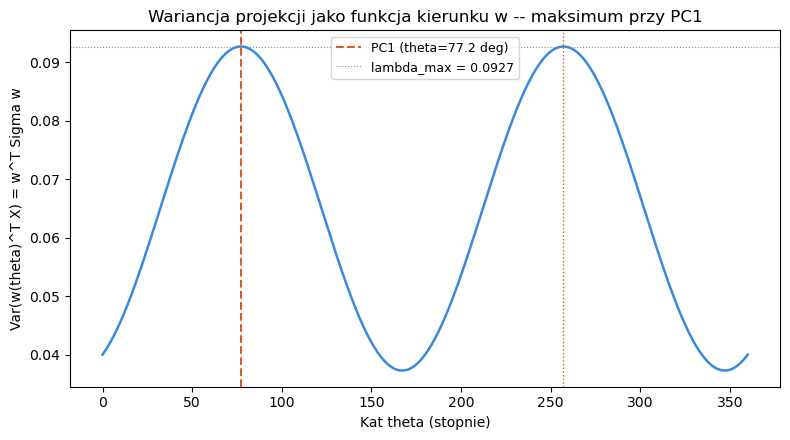

Maksimum funkcji wariancji wypada przy theta=77.2 stopni
-- to jest dokladnie kierunek eigenvectora PC1


In [16]:
# --- Wizualizacja optymalizacji: wariancja jako funkcja kata (w 2D dla prostoty) ---
# Uzyjemy podmacierzy 2x2 zeby zobaczyc to na wykresie

Sigma_2d = Sigma_true[:2, :2]
eigvals_2d, eigvecs_2d = np.linalg.eigh(Sigma_2d)
idx_2d = np.argsort(eigvals_2d)[::-1]
eigvals_2d  = eigvals_2d[idx_2d]
eigvecs_2d  = eigvecs_2d[:, idx_2d]

# Parametryzujemy wektor jednostkowy katem theta: w(theta) = [cos(theta), sin(theta)]
thetas = np.linspace(0, 2*np.pi, 360)
variances = np.array([
    np.array([np.cos(t), np.sin(t)]) @ Sigma_2d @ np.array([np.cos(t), np.sin(t)])
    for t in thetas
])

# Kat odpowiadajacy PC1
theta_pc1 = np.arctan2(eigvecs_2d[1, 0], eigvecs_2d[0, 0])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.degrees(thetas), variances, color='#378ADD', linewidth=1.8)
ax.axvline(np.degrees(theta_pc1) % 360, color='#D85A30', linestyle='--', linewidth=1.5,
           label=f'PC1 (theta={np.degrees(theta_pc1):.1f} deg)')
ax.axvline((np.degrees(theta_pc1) + 180) % 360, color='#D85A30', linestyle=':', linewidth=1)
ax.axhline(eigvals_2d[0], color='#888780', linestyle=':', linewidth=0.8,
           label=f'lambda_max = {eigvals_2d[0]:.4f}')
ax.set_xlabel('Kat theta (stopnie)')
ax.set_ylabel('Var(w(theta)^T X) = w^T Sigma w')
ax.set_title('Wariancja projekcji jako funkcja kierunku w -- maksimum przy PC1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/tmp/pca_optimization.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Maksimum funkcji wariancji wypada przy theta={np.degrees(theta_pc1)%360:.1f} stopni")
print("-- to jest dokladnie kierunek eigenvectora PC1")


---
## 6. Geometria: elipsa kowariancji

### 6.1 Powierzchnie stalej gestosci rozkladu normalnego

Dla $\mathbf{X} \sim N(\mu, \Sigma)$ w $\mathbb{R}^2$, gestosc jest stala na zbiorach:

$$
(\mathbf{x}-\mu)^T \Sigma^{-1} (\mathbf{x}-\mu) = c^2
$$

To jest rownanie **elipsy** (w 2D) lub **elipsoidy** (w wiekszej liczbie wymiarow).

### 6.2 Zwiazek z eigenvectorami

Podstawiajac dekompozycje spektralna $\Sigma = V\Lambda V^T$, mozna pokazac ze:
- **osie elipsy** sa rownolegle do eigenvectorow $\mathbf{v}_i$
- **dlugosc polosi** $i$-tej to $c \cdot \sqrt{\lambda_i}$

Intuicyjnie: $\Sigma^{-1}$ ma te same eigenvectory co $\Sigma$, ale eigenvalues $1/\lambda_i$
(odwrotna macierz ma odwrotne eigenvalues, eigenvectory te same). W ukladzie eigenvectorow
rownanie elipsy "rozdziela sie" na niezalezne kwadraty wzdluz kazdej osi.


In [17]:
# --- Weryfikacja: Sigma^-1 ma te same eigenvectory, odwrotne eigenvalues ---

Sigma_inv = np.linalg.inv(Sigma_2d)
eigvals_inv, eigvecs_inv = np.linalg.eigh(Sigma_inv)
idx_inv = np.argsort(eigvals_inv)[::-1]
eigvals_inv = eigvals_inv[idx_inv]
eigvecs_inv = eigvecs_inv[:, idx_inv]

print("Eigenvalues Sigma:        ", eigvals_2d[::-1].round(6))   # male->duze dla porownania
print("Eigenvalues Sigma^-1:     ", eigvals_inv.round(6))
print("1/Eigenvalues Sigma:      ", (1/eigvals_2d[::-1]).round(6))
print()
print("Eigenvectory Sigma i Sigma^-1 powinny byc identyczne (lub +-):")
print("Sigma:    ", eigvecs_2d[:, ::-1].round(4))
print("Sigma^-1: ", eigvecs_inv.round(4))


Eigenvalues Sigma:         [0.0373 0.0927]
Eigenvalues Sigma^-1:      [26.8318 10.7839]
1/Eigenvalues Sigma:       [26.8318 10.7839]

Eigenvectory Sigma i Sigma^-1 powinny byc identyczne (lub +-):
Sigma:     [[-0.9751  0.2219]
 [ 0.2219  0.9751]]
Sigma^-1:  [[-0.9751 -0.2219]
 [ 0.2219 -0.9751]]


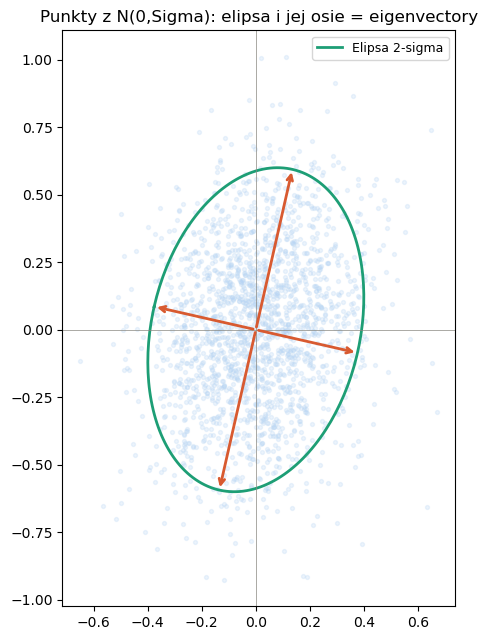

Sekcja 6 - demo gotowe


In [18]:
# --- Wizualizacja elipsy z osiami = eigenvectory ---
np.random.seed(1)
pts = np.random.multivariate_normal([0, 0], Sigma_2d, 2000)

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(pts[:, 0], pts[:, 1], alpha=0.25, s=8, color='#B5D4F4')

# Rysujemy elipse 2-sigma (c=2) parametrycznie
theta_param = np.linspace(0, 2*np.pi, 200)
# w bazie eigenvectorow: elipsa to (2*sqrt(lambda1)*cos, 2*sqrt(lambda2)*sin)
ellipse_local = np.vstack([
    2 * np.sqrt(eigvals_2d[1]) * np.cos(theta_param),   # eigvals_2d posortowane male->duze
    2 * np.sqrt(eigvals_2d[0]) * np.sin(theta_param)
])
# transformujemy do oryginalnej bazy: V @ ellipse_local
V_for_plot = eigvecs_2d[:, ::-1]   # kolumny: [v_max, v_min] zeby zgadzac z lambda max,min
ellipse_global = V_for_plot @ np.vstack([
    2*np.sqrt(eigvals_2d[::-1][0])*np.cos(theta_param),
    2*np.sqrt(eigvals_2d[::-1][1])*np.sin(theta_param)
])

ax.plot(ellipse_global[0], ellipse_global[1], color='#1D9E75', linewidth=2, label='Elipsa 2-sigma')

# Osie eigenvectorow
for val, vec in zip(eigvals_2d[::-1], eigvecs_2d[:, ::-1].T):
    end = 2 * np.sqrt(val) * vec
    ax.annotate('', xy=end, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#D85A30', lw=2))
    ax.annotate('', xy=-end, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#D85A30', lw=2))

ax.set_title('Punkty z N(0,Sigma): elipsa i jej osie = eigenvectory')
ax.axhline(0, color='#888780', linewidth=0.5)
ax.axvline(0, color='#888780', linewidth=0.5)
ax.set_aspect('equal')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/tmp/ellipse_eigenvectors.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sekcja 6 - demo gotowe")


### 6.3 Interpretacja w jednym zdaniu kazdej czesci notebooka

- **Macierz kowariancji** $\Sigma$ — opisuje jak zmienne losowe wspolnie sie zmieniaja
- **Forma kwadratowa** $\mathbf{w}^T\Sigma\mathbf{w}$ — wariancja w dowolnym kierunku $\mathbf{w}$
- **Eigenvalues/eigenvectory** — kierunki w ktorych $\Sigma$ tylko skaluje (nie obraca), i ile skaluje
- **Twierdzenie spektralne** — dla symetrycznej $\Sigma$, eigenvectory sa ortogonalne i tworza pelna baze
- **PCA** — eigenvector z najwiekszym eigenvalue to kierunek **maksymalnej wariancji**;
  caly PCA to po prostu sortowanie eigenvalues malejaco
- **Elipsa ryzyka** — geometryczna wizualizacja: osie elipsy = eigenvectory, dlugosc osi = sqrt(eigenvalue)


---
## Podsumowanie wzorow

In [19]:
summary = """
+==================================================================+
|   MACIERZ KOWARIANCJI, EIGENVALUES/EIGENVECTORY, PCA            |
|   SCIAGAWKA WZOROW                                               |
+==================================================================+
| DEFINICJE                                                        |
|   Cov(X,Y) = E[(X-EX)(Y-EY)]                                     |
|   Sigma_ij = Cov(X_i, X_j)                                       |
|   Sigma = E[(X-mu)(X-mu)^T]                                      |
+==================================================================+
| WLASNOSCI SIGMA                                                  |
|   Symetria:        Sigma = Sigma^T                                |
|   PSD:              w^T Sigma w >= 0  dla kazdego w               |
+==================================================================+
| TRANSFORMACJE                                                    |
|   Y = AX        =>  Cov(Y) = A Sigma A^T                          |
|   Y = w^T X     =>  Var(Y) = w^T Sigma w     (forma kwadratowa)  |
+==================================================================+
| EIGENVALUES / EIGENVECTORY                                       |
|   Definicja:     A v = lambda v                                  |
|   Charakterystyczne: det(A - lambda I) = 0                       |
|   trace(A) = sum(lambda_i)        det(A) = prod(lambda_i)        |
+==================================================================+
| TWIERDZENIE SPEKTRALNE (dla A symetrycznej)                      |
|   - eigenvalues rzeczywiste                                      |
|   - eigenvectory ortogonalne (rozne lambda)                      |
|   - A = V Lambda V^T = sum_i lambda_i v_i v_i^T                  |
|   - V^T V = I  (ortonormalnosc)                                  |
+==================================================================+
| DLA SIGMA (PSD): wszystkie lambda_i >= 0                         |
+==================================================================+
| PCA                                                               |
|   max_{||w||=1} w^T Sigma w  =>  w = eigenvector(lambda_max)     |
|   PC_k = k-ty eigenvector (po sortowaniu lambda malejaco)        |
|   "Wyjasniana wariancja" PC_k = lambda_k / sum(lambda)            |
+==================================================================+
| GEOMETRIA                                                         |
|   Osie elipsy {(x-mu)^T Sigma^-1 (x-mu) = c^2}:                  |
|     kierunek = eigenvectory, dlugosc polosi = c*sqrt(lambda_i)   |
+==================================================================+
"""
print(summary)



+==================================================================+
|   MACIERZ KOWARIANCJI, EIGENVALUES/EIGENVECTORY, PCA            |
|   SCIAGAWKA WZOROW                                               |
+==================================================================+
| DEFINICJE                                                        |
|   Cov(X,Y) = E[(X-EX)(Y-EY)]                                     |
|   Sigma_ij = Cov(X_i, X_j)                                       |
|   Sigma = E[(X-mu)(X-mu)^T]                                      |
+==================================================================+
| WLASNOSCI SIGMA                                                  |
|   Symetria:        Sigma = Sigma^T                                |
|   PSD:              w^T Sigma w >= 0  dla kazdego w               |
+==================================================================+
| TRANSFORMACJE                                                    |
|   Y = AX        =>  Cov(Y) = A